In [ ]:
from google.colab import drive #mount google drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
!pip install opencv-python #just run this
import cv2
import os
from matplotlib import pyplot as plt
from os import environ

from os.path import dirname, abspath
from os import listdir
import os, os.path, time
import time as time
import timeit

from sys import argv
import sys


########### Load Keras Modules Needed ==========================================
import tensorflow as tf
import tensorflow.keras
# import tensorflow.keras.backend as K

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, load_model, Model

from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, \
                                    concatenate, average, add, Reshape, Permute, Conv2D, \
                                    Conv2DTranspose, SeparableConv2D,PReLU, ELU, \
                                    BatchNormalization, \
                                    MaxPooling2D, ZeroPadding2D, UpSampling2D, \
                                    AveragePooling2D,Cropping2D, \
                                    Flatten, Dense, Dropout, Activation, Reshape,\
                                    SpatialDropout2D,Average


from tensorflow.keras.optimizers import RMSprop, SGD, Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping,\
                            LearningRateScheduler, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model,to_categorical,Sequence



# Load other functions ==================================================
import glob

import numpy as np
from numpy import zeros, newaxis
import h5py, pickle
from random import randint, choice, shuffle, sample
from itertools import product

from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from scipy import signal

from PIL import Image, ImageOps

In [ ]:
cam = cv2.VideoCapture("/content/drive/MyDrive/Pupil Videos/AM3.mp4") #Video_path
fps = cam.get(cv2.CAP_PROP_FPS)
fps #result displays the frame rate of the video

30.0

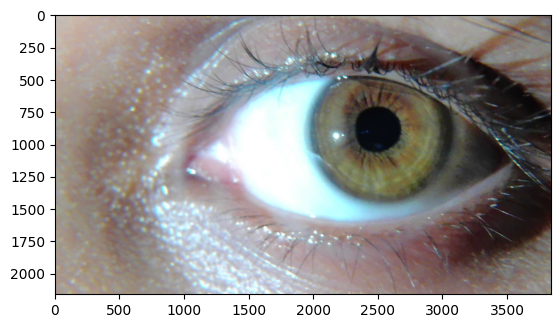

In [ ]:
ret, frame = cam.read()
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)) #This code should give the first frame as the output
plt.show()
cam.release()

In [ ]:
n = 0
cam = cv2.VideoCapture("/content/drive/MyDrive/Pupil Videos/AM3.mp4") # Video file path
success, frame = cam.read()
number = cam.get(cv2.CAP_PROP_FRAME_COUNT) #result is the number of frames
print(number)
print(success)

2423.0
True


Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame:  True
Read a new frame

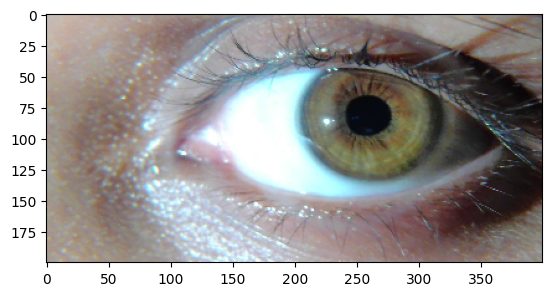

In [ ]:

# Initialize the video capture
cam = cv2.VideoCapture("/content/drive/MyDrive/Pupil Videos/AM3.mp4")
success, frame = cam.read()
count = 0

# Initialize the list to store file paths
# OCT_list = []
img_data = []
# dum = []

while success and count<1200:
    if count % 1 == 0 :
        # Construct the file path
        # file_path = f"/content/drive/MyDrive/Summer Intern/Frames&Labels/frame{count}.jpg"
        # Save frame as JPEG file
        #cv2.imwrite(file_path, frame)

        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        img = cv2.resize(frame_rgb, (400, 200), interpolation=cv2.INTER_LANCZOS4)

        # pil_image = Image.fromarray(frame_rgb)

        # img = pil_image.resize((400,200))

        img_array = np.array(img, dtype=np.float32)

        img_array = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array))

        img_data.append(img_array)
        # Append the file path to the list
        # OCT_list.append(file_path)

    # Read the next frame
    success, frame = cam.read()
    print('Read a new frame: ', success)
    count += 1

# Print the list of file paths
# print(OCT_list)

img_data = np.asarray(img_data)

print("number of new images: ",np.shape(img_data))

plt.imshow(img_data[0])

In [ ]:
def DiceCoeff(y_true, y_pred):
    dice = np.zeros(nb_classes)
    for i in range(nb_classes):
        y_pred111 = np.round(y_pred[:,:,i])
        ttt = np.sum(np.minimum(y_true[:,:,i], y_pred111)) / \
                        (np.sum(y_true[:,:,i])+np.sum(y_pred[:,:,i]))
        dice[i] = 2*ttt
    return np.round(np.sum(dice)/nb_classes,2)

In [ ]:
def jacc_coeff_loss_tissue(y_true, y_pred):
    loss = 0
    for i in range(nb_classes):
        layer_weight = 1.0
        if i == 1:
            layer_weight=2.0
        loss += layer_weight * tf.reduce_sum(tf.minimum(y_true[:,:,:,i], y_pred[:,:,:,i])) / \
                    tf.reduce_sum(tf.maximum(y_true[:,:,:,i], y_pred[:,:,:,i]))
    loss = (1 - loss / nb_classes)
    return loss

In [ ]:
def unet(img_rows, img_cols, nb_classes):

    inputs = tf.keras.Input(shape=(img_rows, img_cols, 3))

    conv1 = Conv2D(8, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(inputs)
    conv1 = Conv2D(8, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = Conv2D(16, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(pool1)
    conv2 = Conv2D(16, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = Conv2D(32, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(pool2)
    conv3 = Conv2D(32, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    conv4 = Conv2D(64, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(pool3)
    conv4 = Conv2D(64, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(conv4)
    drop4 = Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(1, 1))(drop4)

    conv5 = Conv2D(64, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(pool4)
    conv5 = Conv2D(64, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(conv5)
    drop5 = Dropout(0.5)(conv5)

    up6 = Conv2D(64, 2, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (1,1))(drop5))
    merge6 = concatenate([drop4,up6], axis = 3)
    conv6 = Conv2D(64, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(merge6)
    conv6 = Conv2D(64, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(conv6)

    up7 = Conv2D(32, 2, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv6))
    merge7 = concatenate([conv3,up7], axis = 3)
    conv7 = Conv2D(32, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(merge7)
    conv7 = Conv2D(32, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(conv7)

    up8 = Conv2D(16, 2, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv7))
    merge8 = concatenate([conv2,up8], axis = 3)
    conv8 = Conv2D(16, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(merge8)
    conv8 = Conv2D(16, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(conv8)

    up9 = Conv2D(8, 2, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(UpSampling2D(size = (2,2))(conv8))
    merge9 = concatenate([conv1,up9], axis = 3)
    conv9 = Conv2D(8, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(merge9)
    conv9 = Conv2D(8, 3, activation = 'elu', padding = 'same', kernel_initializer = 'he_normal')(conv9)

    conv10 = Conv2D(nb_classes, 1, activation = 'softmax')(conv9)

    model = Model(inputs = [inputs], outputs = [conv10])

    return model

In [ ]:
no_test_images=2066 #Number of testing images

W, H = 400,200 #dimension of each image from the cirrus device
nb_classes=3
print(np.shape(img_data))
# test_images = OCT_img[0:no_test_images]

print(img_data[0][0][0])

(1200, 200, 400, 3)
[0.78039217 0.7411765  0.69411767]


In [ ]:
img_rows=H; img_cols=W

# sgd_1=tf.keras.optimizers.legacy.SGD(learning_rate=0.005, momentum=0.05, decay=0.01, nesterov=False)
# Adam= tf.keras.optimizers.legacy.Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, decay=0.0000003, amsgrad=True)  ###............

from tensorflow.keras.optimizers import SGD, Adam

sgd_1 = SGD(learning_rate=0.005, momentum=0.05, decay=0.01, nesterov=False)
Adam = Adam(learning_rate=0.0001, beta_1=0.9, beta_2=0.999, decay=0.0000003, amsgrad=True)


model = unet(img_rows,img_cols,nb_classes)

# model.compile(optimizer = Adam, loss = 'categorical_crossentropy', metrics = ['accuracy']) # ....
model.compile(optimizer = Adam, loss = jacc_coeff_loss_tissue, metrics = ['accuracy']) # ....


model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 200, 400, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 200, 400, 8)    │            224 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 200, 400, 8)    │            584 │ conv2d_23[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 100, 200, 8)    │              0 │ conv2d_24[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 100, 200, 16)   │          1,168 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 100, 200, 16)   │          2,320 │ conv2d_25[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 50, 100, 16)    │              0 │ conv2d_26[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_27 (Conv2D)        │ (None, 50, 100, 32)    │          4,640 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_28 (Conv2D)        │ (None, 50, 100, 32)    │          9,248 │ conv2d_27[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 25, 50, 32)     │              0 │ conv2d_28[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_29 (Conv2D)        │ (None, 25, 50, 64)     │         18,496 │ max_pooling2d_6[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_30 (Conv2D)        │ (None, 25, 50, 64)     │         36,928 │ conv2d_29[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 25, 50, 64)     │              0 │ conv2d_30[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_7           │ (None, 25, 50, 64)     │              0 │ dropout_2[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_31 (Conv2D)        │ (None, 25, 50, 64)     │         36,928 │ max_pooling2d_7[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_32 (Conv2D)        │ (None, 25, 50, 64)     │         36,928 │ conv2d_31[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 25, 50, 64)     │              0 │ conv2d_32[0][0]        │
├──────────────────────

 Total params: 321,867 (1.23 MB)

 Trainable params: 321,867 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

best_checkpoint=ModelCheckpoint(filepath='/content/drive/MyDrive/Models/best_weights_Result_SY.hdf5',
                             monitor='val_loss',verbose=1,
                             save_best_only=True, save_weights_only=True, mode='auto', period=1)
cur_checkpoint=ModelCheckpoint(filepath='/content/drive/MyDrive/Models/cur_weights_Result_SY.hdf5',
                             monitor='val_loss',verbose=0,
                             save_best_only=False, save_weights_only=True, mode='auto', period=1)

lrScheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5,patience=3, cooldown=0, verbose=1,min_lr=1e-7)

# model.load_weights(imgpath+'/Model_checkpoints/best_weights_'+testname+'.hdf5')

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

best_checkpoint = ModelCheckpoint(filepath='/content/drive/MyDrive/Models/best_weights_Result.weights.h5',
                                  monitor='val_loss', verbose=1,
                                  save_best_only=True, save_weights_only=True, mode='auto', save_freq='epoch')

cur_checkpoint = ModelCheckpoint(filepath='/content/drive/MyDrive/Models/cur_weights_Result.weights.h5',
                                 monitor='val_loss', verbose=0,
                                 save_best_only=False, save_weights_only=True, mode='auto', save_freq='epoch')

lrScheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, cooldown=0, verbose=1, min_lr=1e-7)

# model.load_weights(imgpath+'/Model_checkpoints/best_weights_'+testname+'.weights.h5')


In [ ]:
model = load_model('/content/drive/MyDrive/Models/Result_SY.h5',custom_objects={'jacc_coeff_loss_tissue': jacc_coeff_loss_tissue})
# model.load_weights('/content/drive/MyDrive/Iris_Contraction/downsampled/Model_checkpoints/Iris_segmentation.hdf5')
print('model loaded successfully')

model loaded successfully


In [ ]:
# Assuming test_images is a tuple of 32 arrays, stack them into a single array
img_data = np.stack(img_data, axis=0)

# Now use the stacked array for prediction
label_data = model.predict(img_data)

print(np.shape(label_data))
print('Predictions obtained ....')

29/29 [==============================] - 113s 4s/step
(901, 200, 400, 3)
Predictions obtained ....


In [ ]:
import numpy as np

# Define a function to process data in batches
def predict_in_batches(model, data, batch_size=32):
    num_batches = len(data) // batch_size + (1 if len(data) % batch_size != 0 else 0)
    label_data = []

    for i in range(num_batches):
        batch_start = i * batch_size
        batch_end = (i + 1) * batch_size
        batch = np.stack(data[batch_start:batch_end], axis=0)
        batch_predictions = model.predict(batch)
        label_data.append(batch_predictions)

    label_data = np.concatenate(label_data, axis=0)
    return label_data

# Assuming img_data is a list of images
label_data = predict_in_batches(model, img_data, batch_size=32)

print(np.shape(label_data))
print('Predictions obtained ....')


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 

(1200, 256, 512, 3)
(1200, 256, 512, 3)
Total images in OCT_img: 1200
Total images in OCT_label: 1200


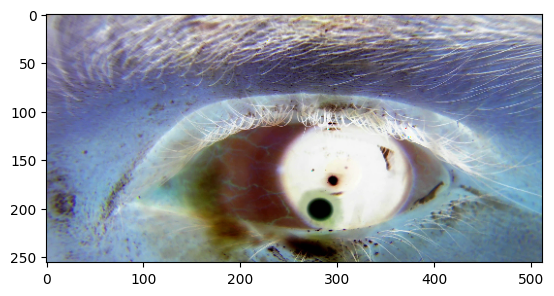

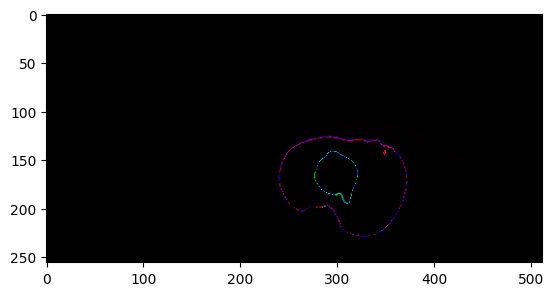

Total blended images created: 1200


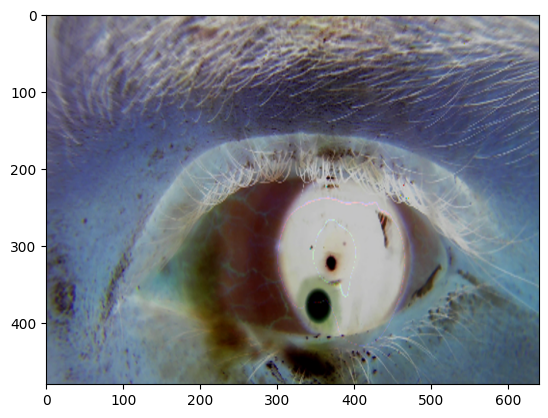

In [ ]:
# img_data=test_images
# label_data=test_preds
print(np.shape(img_data))
print(np.shape(label_data))
plt.imshow(label_data[450])

img_data = (img_data * 255).astype(np.uint8)
label_data = (label_data * 255).astype(np.uint8)

Pred_img = [Image.fromarray(img_data[i]) for i in range(img_data.shape[0])]

# Convert each image in label_data to a Pillow image and store in a list
Pred_label = [Image.fromarray(label_data[i]) for i in range(label_data.shape[0])]

# Print the number of images stored in each list
print(f"Total images in OCT_img: {len(Pred_img)}")
print(f"Total images in OCT_label: {len(Pred_label)}")

# Optionally, display the first image from each list to verify
plt.imshow(Pred_img[450])
plt.show()
plt.imshow(Pred_label[450])
plt.show()

Res_img = []

for img, label in zip(Pred_img, Pred_label):
    # Ensure both images are in RGBA mode
    img = img.convert("RGBA")
    label = label.convert("RGBA")

    # Blend the images with 20% transparency for the label image
    blended_img = Image.blend(img, label, alpha=0.2)

    target_width, target_height = 640, 480
    blended_img = blended_img.resize((target_width, target_height))

    # Append the blended image to the list
    Res_img.append(blended_img)

# Print the number of blended images created
print(f"Total blended images created: {len(Res_img)}")

# Optionally, display the first blended image to verify
plt.imshow(Res_img[450])
plt.show()

In [ ]:
def process_label(label):
    # Placeholder function to process labels, adjust as needed
    return label

@interact(x=(0, len(img_data) - 1, 1))  # Slider from 0 to len(img_data) - 1 with step size of 1
def h(x=0):  # Default starting value of the slider is 0
    print(f"x: {x}, type of x: {type(x)}")

    # Check the shape and type of the selected image
    selected_img = img_data[x]
    print(f"selected_img shape: {selected_img.shape}, type: {type(selected_img)}")

    # Check the shape and type of the processed label
    # selected_label_data2 = np.argmax(label_data2[x], axis=2) + 1
    # print(f"selected_label_data2 shape: {selected_label_data2.shape}, type: {type(selected_label_data2)}")

    selected_label_data = np.argmax(label_data[x], axis=2) + 1
    print(f"selected_label_data shape: {selected_label_data.shape}, type: {type(selected_label_data)}")

    f = plt.figure(figsize=(12, 6))
    plt.rcParams.update({'font.size': 12})
    f.subplots_adjust(left=0.02, right=0.75, wspace=0.01, hspace=0.3)

    f.add_subplot(1, 2, 1)
    plt.imshow(img_data[x], cmap='gray')
    plt.title("Test image")

    # f.add_subplot(2, 2, 2)
    # color_label2 = process_label(selected_label_data2)
    # plt.imshow(color_label2)
    # plt.title("Manual segmentation")

    # f.add_subplot(2, 2, 3)
    # plt.imshow(img_data[x], cmap='gray')
    # plt.imshow(color_label2, alpha=0.3)
    # plt.title("Test image with manual segmentation")

    f.add_subplot(1, 2, 2)
    color_label = process_label(selected_label_data)
    plt.imshow(color_label)
    plt.title("Network prediction")

    plt.show()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import gc

def process_and_predict_in_batches(video_path, model, batch_size=64):
    # Initialize the video capture
    cam = cv2.VideoCapture(video_path)
    success, frame = cam.read()
    count = 0

    # Initialize lists to store image data and predictions
    img_data = []
    label_data = []

    # Temporary list to store current batch of images
    current_batch = []

    while success:
        if count % 1 == 0:
            # Convert frame from BGR to RGB
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Resize the frame
            img = cv2.resize(frame_rgb, (512, 256), interpolation=cv2.INTER_LANCZOS4)

            # Normalize the image
            img_array = np.array(img, dtype=np.float32)
            img_array = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array))

            # Add the processed image to the current batch
            current_batch.append(img_array)

            # If the current batch is full, perform prediction and clear memory
            if len(current_batch) == batch_size:
                # Convert current batch to numpy array
                batch_array = np.stack(current_batch, axis=0)

                # Perform prediction
                batch_predictions = model.predict(batch_array)

                # Append the current batch images and predictions to the main lists
                img_data.extend(current_batch)
                label_data.extend(batch_predictions)

                # Clear the current batch and run garbage collection
                current_batch = []
                gc.collect()

        # Read the next frame
        success, frame = cam.read()
        print('Read a new frame: ', success)
        count += 1

    # Process any remaining images in the current batch
    if len(current_batch) > 0:
        batch_array = np.stack(current_batch, axis=0)
        batch_predictions = model.predict(batch_array)
        img_data.extend(current_batch)
        label_data.extend(batch_predictions)
        gc.collect()

    # Convert lists to numpy arrays
    img_data = np.asarray(img_data)
    label_data = np.asarray(label_data)

    return img_data, label_data

# Example usage
video_path = "/content/drive/MyDrive/RawVideos/A5.mp4"
batch_size = 64  # Adjust batch size based on memory constraints

# Assuming `model` is already loaded
img_data, label_data = process_and_predict_in_batches(video_path, model, batch_size)

# Print results
print("Number of processed images: ", np.shape(img_data))
print("Number of predictions: ", np.shape(label_data))

# Display the first processed image and its corresponding prediction
plt.imshow(img_data[0])
plt.title('First Processed Frame')
plt.axis('off')
plt.show()

print('Predictions obtained ....')


In [ ]:
import cv2
import numpy as np
from PIL import Image
import gc

img_data = (img_data * 255).astype(np.uint8)
label_data = (label_data * 255).astype(np.uint8)

Pred_img = [Image.fromarray(img_data[i]) for i in range(img_data.shape[0])]

# Convert each image in label_data to a Pillow image and store in a list
Pred_label = [Image.fromarray(label_data[i]) for i in range(label_data.shape[0])]

# Function to convert and resize image
def process_image(img, label, target_size):
    # img = img.convert("RGBA")
    # label = label.convert("RGBA")
    blended_img = Image.blend(img, label, alpha=0.2)
    resized_img = blended_img.resize(target_size)
    return resized_img

# Target dimensions
target_width, target_height = 3840, 2160
target_size = (target_width, target_height)

# Video writer setup
output_video_path = "/content/drive/MyDrive/SegmentedVideos/AB2_a.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = 30  # Adjust the frame rate as needed
out = cv2.VideoWriter(output_video_path, fourcc, fps, target_size)

# Batch processing parameters
batch_size = 300
num_batches = len(Pred_img) // batch_size + (1 if len(Pred_img) % batch_size != 0 else 0)

# Exponential smoothing factor
alpha = 0.4

# Initialize the first smoothed image
first_img = process_image(Pred_img[0], Pred_label[0], target_size)
smoothed_image = np.array(first_img)

# Process in batches
for batch in range(num_batches):
    start_idx = batch * batch_size
    end_idx = min((batch + 1) * batch_size, len(Pred_img))

    for i in range(start_idx, end_idx):
        current_image = process_image(Pred_img[i], Pred_label[i], target_size)
        current_image_np = np.array(current_image)
        smoothed_image = alpha * current_image_np + (1 - alpha) * smoothed_image
        smoothed_image_pil = Image.fromarray(smoothed_image.astype(np.uint8))

        # Convert to BGR for OpenCV
        smoothed_image_bgr = cv2.cvtColor(np.array(smoothed_image_pil), cv2.COLOR_RGBA2BGR)
        out.write(smoothed_image_bgr)

    # Clear memory after each batch
    gc.collect()

# Release the VideoWriter object
out.release()

print(f"Video saved at {output_video_path}")


Video saved at /content/drive/MyDrive/SegmentedVideos/N2.mp4


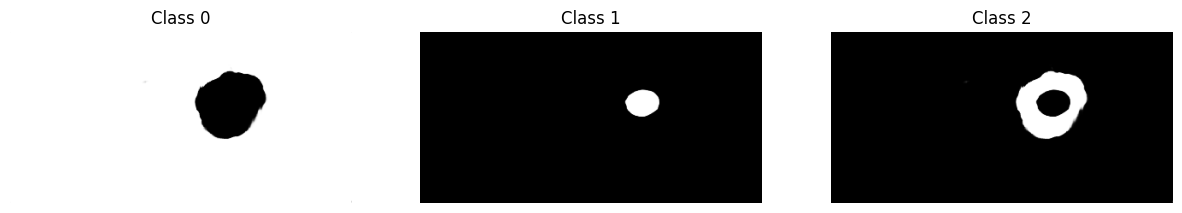

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming prediction_array is your 4D array (num_images, width, height, num_classes)
def identify_pupil_class(prediction_array, frame_index=0):
    num_classes = prediction_array.shape[-1]

    fig, axs = plt.subplots(1, num_classes, figsize=(15, 5))
    for i in range(num_classes):
        class_mask = prediction_array[frame_index, :, :, i]
        axs[i].imshow(class_mask, cmap='gray')
        axs[i].set_title(f'Class {i}')
        axs[i].axis('off')
    plt.show()

# Example usage
# prediction_array = your_4d_prediction_array
identify_pupil_class(label_data)


In [ ]:
import cv2
import numpy as np
from PIL import Image
import gc
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Function to calculate pupil diameter
def calculate_pupil_diameter(prediction, pupil_class=1):
    pupil_mask = (prediction > 0.5).astype(np.uint8) * 255  # Ensure binary mask with values 0 and 255
    contours, _ = cv2.findContours(pupil_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        (x, y), radius = cv2.minEnclosingCircle(largest_contour)
        return radius * 2
    else:
        return 0

# Function to convert and resize image
def process_image(img, label, target_size):
    blended_img = Image.blend(img, label, alpha=0.2)
    resized_img = blended_img.resize(target_size)
    return resized_img

# Assuming img_data and label_data are initialized correctly
# img_data = ... # Your image data here
# label_data = ... # Your label data here

# Convert img_data and label_data to uint8
img_data = (img_data * 255).astype(np.uint8)
label_data = (label_data * 255).astype(np.uint8)

# Convert each frame to a Pillow image
Pred_img = [Image.fromarray(img_data[i]) for i in range(img_data.shape[0])]
Pred_label = [Image.fromarray(label_data[i]) for i in range(label_data.shape[0])]

# Target dimensions
target_width, target_height = 3840, 2160
target_size = (target_width, target_height)

# Video writer setup
output_video_path = "/content/drive/MyDrive/SegmentedVideos/VD2_a.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = 30  # Adjust the frame rate as needed
out = cv2.VideoWriter(output_video_path, fourcc, fps, target_size)

# Batch processing parameters
batch_size = 300
num_batches = len(Pred_img) // batch_size + (1 if len(Pred_img) % batch_size != 0 else 0)

# Exponential smoothing factor
alpha = 0.4

# Initialize the first smoothed image
first_img = process_image(Pred_img[0], Pred_label[0], target_size)
smoothed_image = np.array(first_img)

# List to store pupil diameters
pupil_diameters = []

# Process in batches
for batch in range(num_batches):
    start_idx = batch * batch_size
    end_idx = min((batch + 1) * batch_size, len(Pred_img))

    for i in range(start_idx, end_idx):
        current_image = process_image(Pred_img[i], Pred_label[i], target_size)
        current_image_np = np.array(current_image)
        smoothed_image = alpha * current_image_np + (1 - alpha) * smoothed_image
        smoothed_image_pil = Image.fromarray(smoothed_image.astype(np.uint8))

        # Convert to BGR for OpenCV
        smoothed_image_bgr = cv2.cvtColor(np.array(smoothed_image_pil), cv2.COLOR_RGBA2BGR)
        out.write(smoothed_image_bgr)

        # Calculate and store pupil diameter
        prediction = label_data[i, :, :, 1]  # Use the correct frame prediction for the pupil class
        diameter = calculate_pupil_diameter(prediction)
        pupil_diameters.append(diameter)

    # Clear memory after each batch
    gc.collect()

# Release the VideoWriter object
out.release()

# Ensure there are pupil diameters to plot
if not pupil_diameters:
    print("No pupil diameters calculated.")
else:
    # Setup for real-time plotting
    fig, ax = plt.subplots()
    x_data = list(range(len(pupil_diameters)))
    y_data = pupil_diameters
    line, = ax.plot([], [], lw=2)
    ax.set_xlim(0, len(pupil_diameters))
    ax.set_ylim(0, 80)  # Set y-axis limit to between 30 and 50

    def init():
        line.set_data([], [])
        return line,

    def update(frame):
        line.set_data(x_data[:frame], y_data[:frame])
        return line,

    ani = animation.FuncAnimation(fig, update, frames=len(pupil_diameters), init_func=init, blit=True)

    # Show the real-time plot
    plt.show()

print(f"Video saved at {output_video_path}")


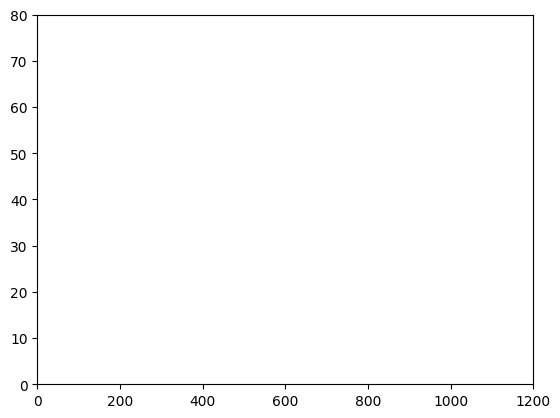

Video saved at /content/drive/MyDrive/SegmentedVideos/AM3_a.mp4


In [ ]:
import cv2
import numpy as np
from PIL import Image
import gc
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Function to calculate pupil diameter and center
def calculate_pupil_properties(prediction, pupil_class=1):
    pupil_mask = (prediction > 0.5).astype(np.uint8) * 255  # Ensure binary mask with values 0 and 255
    contours, _ = cv2.findContours(pupil_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        (x, y), radius = cv2.minEnclosingCircle(largest_contour)
        return (int(x), int(y)), radius * 2
    else:
        return (0, 0), 0

# Function to convert, resize, and translate image
def process_image(img, label, target_size, center):
    blended_img = Image.blend(img, label, alpha=0.2)
    blended_img_np = np.array(blended_img)

    # Calculate translation needed to center the pupil
    h, w, _ = blended_img_np.shape
    center_x, center_y = center
    translation_matrix = np.float32([[1, 0, w//2 - center_x], [0, 1, h//2 - center_y]])

    translated_img = cv2.warpAffine(blended_img_np, translation_matrix, (w, h))
    resized_img = Image.fromarray(translated_img).resize(target_size)
    return resized_img

# Assuming img_data and label_data are initialized correctly
# img_data = ... # Your image data here
# label_data = ... # Your label data here

# Convert img_data and label_data to uint8
img_data = (img_data * 255).astype(np.uint8)
label_data = (label_data * 255).astype(np.uint8)

# Convert each frame to a Pillow image
Pred_img = [Image.fromarray(img_data[i]) for i in range(img_data.shape[0])]
Pred_label = [Image.fromarray(label_data[i]) for i in range(label_data.shape[0])]

# Target dimensions
target_width, target_height = 3840, 2160
target_size = (target_width, target_height)

# Video writer setup
output_video_path = "/content/drive/MyDrive/SegmentedVideos/AM3_a.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = 30  # Adjust the frame rate as needed
out = cv2.VideoWriter(output_video_path, fourcc, fps, target_size)

# Batch processing parameters
batch_size = 300
num_batches = len(Pred_img) // batch_size + (1 if len(Pred_img) % batch_size != 0 else 0)

# Exponential smoothing factor
alpha = 0.4

# Initialize the first smoothed image
first_center, _ = calculate_pupil_properties(label_data[0, :, :, 1])
first_img = process_image(Pred_img[0], Pred_label[0], target_size, first_center)
smoothed_image = np.array(first_img)

# List to store pupil diameters
pupil_diameters = []

# Process in batches
for batch in range(num_batches):
    start_idx = batch * batch_size
    end_idx = min((batch + 1) * batch_size, len(Pred_img))

    for i in range(start_idx, end_idx):
        prediction = label_data[i, :, :, 1]  # Use the correct frame prediction for the pupil class
        center, diameter = calculate_pupil_properties(prediction)
        current_image = process_image(Pred_img[i], Pred_label[i], target_size, center)
        current_image_np = np.array(current_image)
        smoothed_image = alpha * current_image_np + (1 - alpha) * smoothed_image
        smoothed_image_pil = Image.fromarray(smoothed_image.astype(np.uint8))

        # Convert to BGR for OpenCV
        smoothed_image_bgr = cv2.cvtColor(np.array(smoothed_image_pil), cv2.COLOR_RGBA2BGR)
        out.write(smoothed_image_bgr)

        # Store pupil diameter
        pupil_diameters.append(diameter)

    # Clear memory after each batch
    gc.collect()

# Release the VideoWriter object
out.release()

# Ensure there are pupil diameters to plot
if not pupil_diameters:
    print("No pupil diameters calculated.")
else:
    # Setup for real-time plotting
    fig, ax = plt.subplots()
    x_data = list(range(len(pupil_diameters)))
    y_data = pupil_diameters
    line, = ax.plot([], [], lw=2)
    ax.set_xlim(0, len(pupil_diameters))
    ax.set_ylim(0, 80)  # Set y-axis limit to between 0 and 80

    def init():
        line.set_data([], [])
        return line,

    def update(frame):
        line.set_data(x_data[:frame], y_data[:frame])
        return line,

    ani = animation.FuncAnimation(fig, update, frames=len(pupil_diameters), init_func=init, blit=True)

    # Show the real-time plot
    plt.show()

print(f"Video saved at {output_video_path}")


In [ ]:
import cv2
import numpy as np
from PIL import Image
import gc
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import concurrent.futures

# Function to calculate pupil diameter and center
def calculate_pupil_properties(prediction, pupil_class=1):
    pupil_mask = (prediction > 0.5).astype(np.uint8) * 255  # Ensure binary mask with values 0 and 255
    contours, _ = cv2.findContours(pupil_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        (x, y), radius = cv2.minEnclosingCircle(largest_contour)
        return (int(x), int(y)), radius * 2
    else:
        return (0, 0), 0

# Function to convert, resize, and translate image
def process_image(img, label, target_size, center):
    blended_img = Image.blend(img, label, alpha=0.2)
    blended_img_np = np.array(blended_img)

    # Calculate translation needed to center the pupil
    h, w, _ = blended_img_np.shape
    center_x, center_y = center
    translation_matrix = np.float32([[1, 0, w//2 - center_x], [0, 1, h//2 - center_y]])

    translated_img = cv2.warpAffine(blended_img_np, translation_matrix, (w, h))
    resized_img = Image.fromarray(translated_img).resize(target_size)
    return resized_img

# Function to process each frame
def process_frame(i):
    prediction = label_data[i, :, :, 1]  # Use the correct frame prediction for the pupil class
    center, diameter = calculate_pupil_properties(prediction)
    current_image = process_image(Pred_img[i], Pred_label[i], target_size, center)
    current_image_np = np.array(current_image)
    return current_image_np, diameter

# Assuming img_data and label_data are initialized correctly
# img_data = ... # Your image data here
# label_data = ... # Your label data here

# Convert img_data and label_data to uint8
img_data = (img_data * 255).astype(np.uint8)
label_data = (label_data * 255).astype(np.uint8)

# Convert each frame to a Pillow image
Pred_img = [Image.fromarray(img_data[i]) for i in range(img_data.shape[0])]
Pred_label = [Image.fromarray(label_data[i]) for i in range(label_data.shape[0])]

# Target dimensions
target_width, target_height = 3840, 2160
target_size = (target_width, target_height)

# Video writer setup
output_video_path = "/content/drive/MyDrive/SegmentedVideos/AM1_a.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
fps = 30  # Adjust the frame rate as needed
out = cv2.VideoWriter(output_video_path, fourcc, fps, target_size)

# Batch processing parameters
batch_size = 300
num_batches = len(Pred_img) // batch_size + (1 if len(Pred_img) % batch_size != 0 else 0)

# Exponential smoothing factor
alpha = 0.4

# Initialize the first smoothed image
first_center, _ = calculate_pupil_properties(label_data[0, :, :, 1])
first_img = process_image(Pred_img[0], Pred_label[0], target_size, first_center)
smoothed_image = np.array(first_img)

# List to store pupil diameters
pupil_diameters = []

# Process in batches
for batch in range(num_batches):
    start_idx = batch * batch_size
    end_idx = min((batch + 1) * batch_size, len(Pred_img))

    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = [executor.submit(process_frame, i) for i in range(start_idx, end_idx)]
        for future in concurrent.futures.as_completed(futures):
            current_image_np, diameter = future.result()
            smoothed_image = alpha * current_image_np + (1 - alpha) * smoothed_image
            smoothed_image_pil = Image.fromarray(smoothed_image.astype(np.uint8))

            # Convert to BGR for OpenCV
            smoothed_image_bgr = cv2.cvtColor(np.array(smoothed_image_pil), cv2.COLOR_RGBA2BGR)
            out.write(smoothed_image_bgr)

            # Store pupil diameter
            pupil_diameters.append(diameter)

    # Clear memory after each batch
    gc.collect()

# Release the VideoWriter object
out.release()

# Ensure there are pupil diameters to plot
if not pupil_diameters:
    print("No pupil diameters calculated.")
else:
    # Setup for real-time plotting
    fig, ax = plt.subplots()
    x_data = list(range(len(pupil_diameters)))
    y_data = pupil_diameters
    line, = ax.plot([], [], lw=2)
    ax.set_xlim(0, len(pupil_diameters))
    ax.set_ylim(0, 80)  # Set y-axis limit to between 0 and 80

    def init():
        line.set_data([], [])
        return line,

    def update(frame):
        line.set_data(x_data[:frame], y_data[:frame])
        return line,

    ani = animation.FuncAnimation(fig, update, frames=len(pupil_diameters), init_func=init, blit=True)

    # Show the real-time plot
    plt.show()

print(f"Video saved at {output_video_path}")


In [ ]:
print(pupil_diameters)

[32.61307907104492, 32.430877685546875, 32.364009857177734, 32.364009857177734, 32.62553024291992, 32.60483932495117, 33.19707489013672, 32.643070220947266, 32.39817428588867, 32.39817428588867, 32.39817428588867, 32.453983306884766, 32.39817428588867, 32.39817428588867, 32.75019836425781, 32.39817428588867, 32.44272232055664, 32.49049758911133, 32.49049758911133, 32.49049758911133, 32.49049758911133, 32.81090545654297, 32.81090545654297, 32.329132080078125, 32.329132080078125, 23.769927978515625, 0.00019999999494757503, 0.00019999999494757503, 33.25099182128906, 33.25099182128906, 33.5792121887207, 33.015567779541016, 33.033348083496094, 33.064300537109375, 33.362552642822266, 33.362552642822266, 33.362552642822266, 34.16102600097656, 34.16102600097656, 33.34237289428711, 32.71324920654297, 34.019081115722656, 34.0589714050293, 34.07698440551758, 34.07698440551758, 33.54905700683594, 33.54905700683594, 32.97188949584961, 31.645204544067383, 0.00019999999494757503, 0.000199999994947575

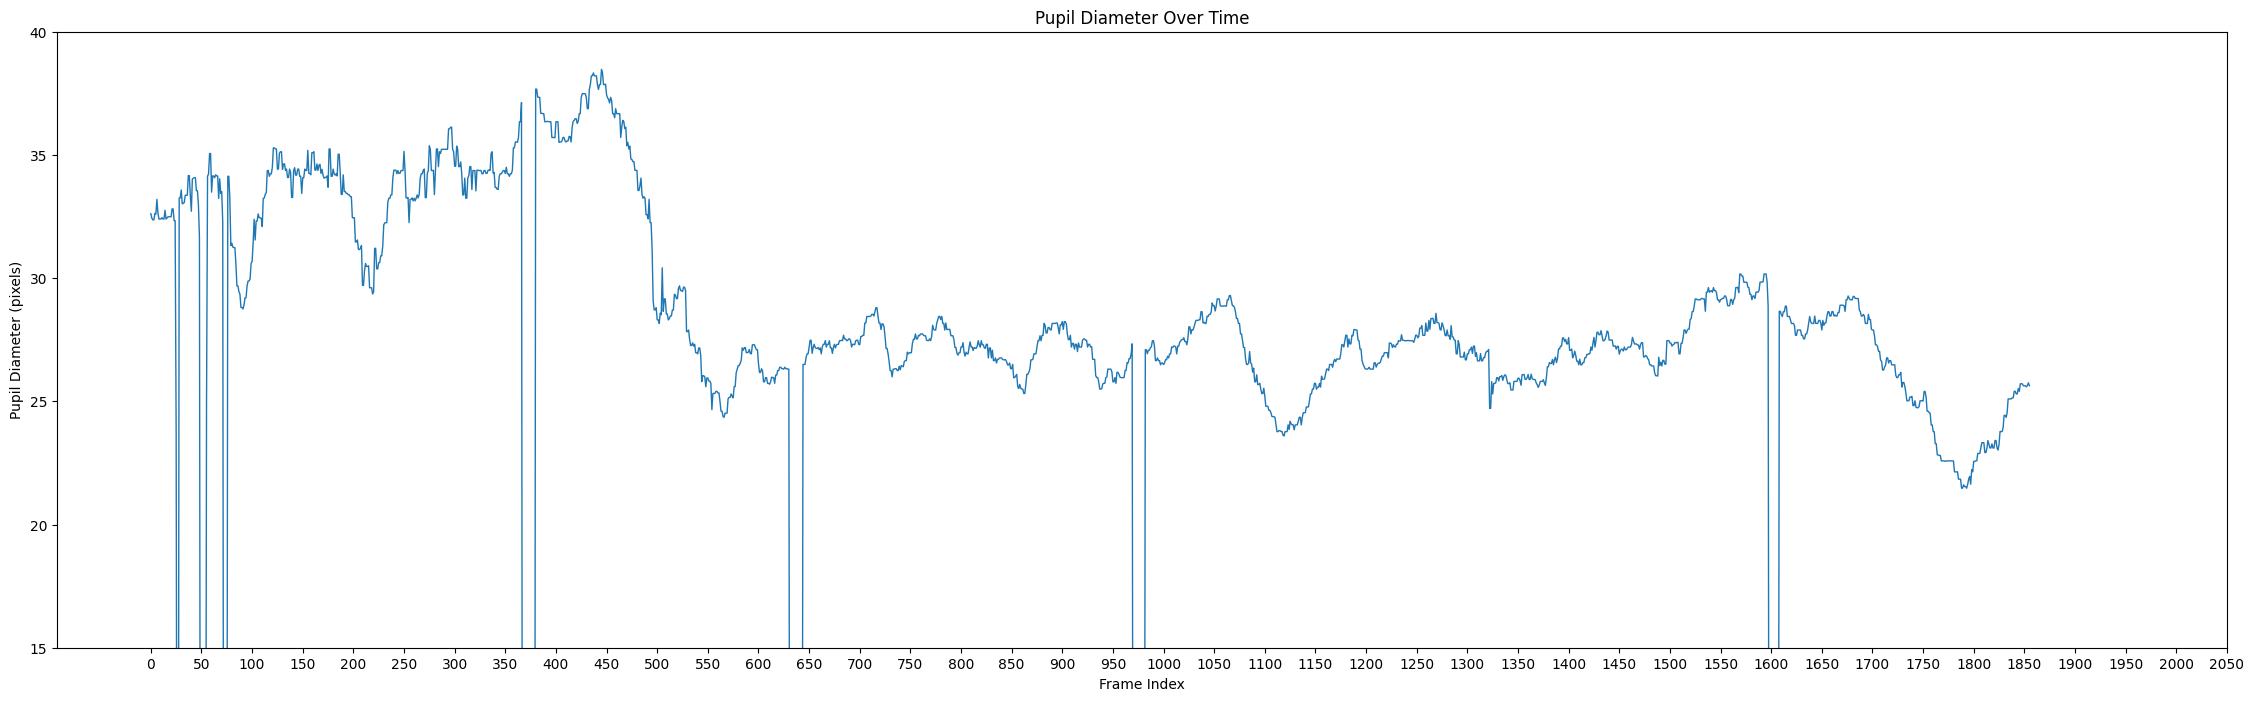

In [ ]:
import matplotlib.pyplot as plt

# Assuming pupil_diameters is your list of pupil diameters

# Create a figure and axis with a larger size
fig, ax = plt.subplots(figsize=(28, 8))  # Width=12 inches, Height=8 inches

# Plot the pupil diameters
ax.plot(range(len(pupil_diameters)), pupil_diameters, lw=1)

# Set the y-axis limit between 20 and 50
ax.set_ylim(15, 40)

# Set the y-axis ticks with a scale of 5 units
ax.set_xticks(range(0, 2100, 50))

# Set the x-axis label and y-axis label
ax.set_xlabel('Frame Index')
ax.set_ylabel('Pupil Diameter (pixels)')

# Set the title of the plot
ax.set_title('Pupil Diameter Over Time')

# Save the plot as a PNG file
plt.savefig('pupil_diameter_over_time.png')

# Display the plot
plt.show()
